**Install dependencies**

In [8]:
!pip install --quiet open3d==0.19.0 imageio scipy

**Download & extract TUM RGB-D dataset (freiburg1_xyz)**

In [9]:
!wget -q http://vision.in.tum.de/rgbd/dataset/freiburg1/rgbd_dataset_freiburg1_xyz.tgz
!tar -xvzf rgbd_dataset_freiburg1_xyz.tgz

rgbd_dataset_freiburg1_xyz/
rgbd_dataset_freiburg1_xyz/accelerometer.txt
rgbd_dataset_freiburg1_xyz/rgb/
rgbd_dataset_freiburg1_xyz/rgb/1305031107.143260.png
rgbd_dataset_freiburg1_xyz/rgb/1305031125.650575.png
rgbd_dataset_freiburg1_xyz/rgb/1305031106.711508.png
rgbd_dataset_freiburg1_xyz/rgb/1305031119.747193.png
rgbd_dataset_freiburg1_xyz/rgb/1305031114.211303.png
rgbd_dataset_freiburg1_xyz/rgb/1305031103.743326.png
rgbd_dataset_freiburg1_xyz/rgb/1305031124.249327.png
rgbd_dataset_freiburg1_xyz/rgb/1305031103.543444.png
rgbd_dataset_freiburg1_xyz/rgb/1305031124.850535.png
rgbd_dataset_freiburg1_xyz/rgb/1305031105.211268.png
rgbd_dataset_freiburg1_xyz/rgb/1305031110.311404.png
rgbd_dataset_freiburg1_xyz/rgb/1305031107.343509.png
rgbd_dataset_freiburg1_xyz/rgb/1305031112.043270.png
rgbd_dataset_freiburg1_xyz/rgb/1305031107.411271.png
rgbd_dataset_freiburg1_xyz/rgb/1305031120.315196.png
rgbd_dataset_freiburg1_xyz/rgb/1305031106.075330.png
rgbd_dataset_freiburg1_xyz/rgb/1305031114.57923

**Import libraries**

In [10]:
import os
import imageio
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
import open3d as o3d   # for PLY export & visualization

**Load RGB-D data**

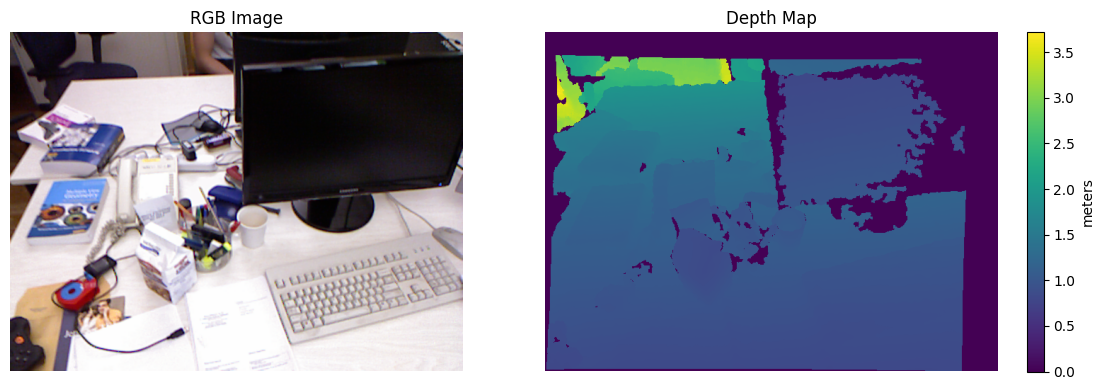

In [11]:
rgb_dir = "rgbd_dataset_freiburg1_xyz/rgb"
depth_dir = "rgbd_dataset_freiburg1_xyz/depth"

rgb_files = sorted(os.listdir(rgb_dir))
depth_files = sorted(os.listdir(depth_dir))

# Load one RGB-D pair
rgb = imageio.v2.imread(os.path.join(rgb_dir, rgb_files[10]))
depth = imageio.v2.imread(os.path.join(depth_dir, depth_files[10])).astype(np.float32) / 5000.0  # depth in meters

# Display RGB and depth
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1); plt.imshow(rgb); plt.title("RGB Image"); plt.axis("off")
plt.subplot(1, 2, 2); plt.imshow(depth, cmap='viridis'); plt.title("Depth Map"); plt.colorbar(label='meters'); plt.axis("off")
plt.tight_layout(); plt.show()

**Step 1: Convert depth map → 3D point cloud**

Point cloud shape: (230497, 3)


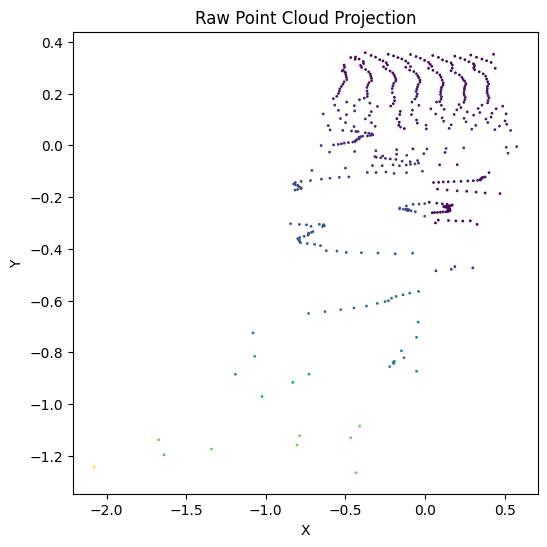

In [12]:
# Camera intrinsics (TUM RGB-D)
fx, fy = 517.3, 516.5  # focal lengths
cx, cy = 318.6, 255.3  # principal point

h, w = depth.shape
i, j = np.meshgrid(np.arange(w), np.arange(h))
z = depth
x = (i - cx) * z / fx
y = (j - cy) * z / fy

pcd = np.dstack((x, y, z))
mask = (z > 0)
pcd = pcd[mask]

print("Point cloud shape:", pcd.shape)

# Visualize raw point cloud projection (XY plane)
plt.figure(figsize=(6,6))
plt.scatter(pcd[::500,0], pcd[::500,1], c=pcd[::500,2], cmap="viridis", s=1)
plt.xlabel("X"); plt.ylabel("Y"); plt.title("Raw Point Cloud Projection")
plt.show()

**Step 2: Define ICP (Iterative Closest Point) Registration**

    ICP minimizes:
        E(R, t) = Σ || p_i - (R q_j + t) ||²
            where p_i are source points, q_j are nearest target points, and (R, t) is rigid transform.

In [13]:
def best_fit_transform(A, B):
    """Compute R, t to align point sets A→B using SVD"""
    assert A.shape == B.shape
    centroid_A = np.mean(A, axis=0)
    centroid_B = np.mean(B, axis=0)

    AA = A - centroid_A
    BB = B - centroid_B

    H = AA.T @ BB
    U, S, Vt = np.linalg.svd(H)
    R = Vt.T @ U.T
    if np.linalg.det(R) < 0:
        Vt[-1,:] *= -1
        R = Vt.T @ U.T
    t = centroid_B - R @ centroid_A
    return R, t

def icp(A, B, max_iterations=20, tolerance=1e-5):
    """Iterative Closest Point"""
    src = np.copy(A)
    prev_error = 0

    for i in range(max_iterations):
        tree = cKDTree(B)
        distances, indices = tree.query(src)
        matched_B = B[indices]

        R, t = best_fit_transform(src, matched_B)
        src = (R @ src.T).T + t

        mean_error = np.mean(distances)
        if np.abs(prev_error - mean_error) < tolerance:
            break
        prev_error = mean_error
    return R, t, src

**Step 3: Apply ICP on two views**

    To simulate, take the same point cloud and apply a known rigid transform

In [14]:
def random_transform(points):
    theta = np.deg2rad(10)  # rotate 10°
    R = np.array([[np.cos(theta), -np.sin(theta), 0],
                  [np.sin(theta),  np.cos(theta), 0],
                  [0, 0, 1]])
    t = np.array([0.05, -0.02, 0.01])
    return (R @ points.T).T + t

A = pcd[::50]   # source (downsampled for speed)
B = random_transform(A)  # target

# Run ICP
R, t, A_aligned = icp(A, B)

**Step 4: Visualization**

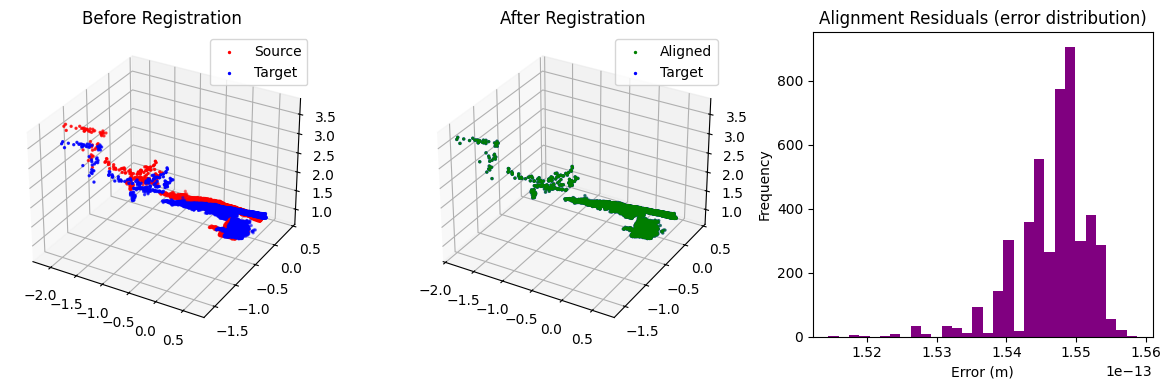

In [15]:
fig = plt.figure(figsize=(12,4))

ax1 = fig.add_subplot(131, projection="3d")
ax1.scatter(A[:,0], A[:,1], A[:,2], c='r', s=2, label='Source')
ax1.scatter(B[:,0], B[:,1], B[:,2], c='b', s=2, label='Target')
ax1.set_title("Before Registration")
ax1.legend()

ax2 = fig.add_subplot(132, projection="3d")
ax2.scatter(A_aligned[:,0], A_aligned[:,1], A_aligned[:,2], c='g', s=2, label='Aligned')
ax2.scatter(B[:,0], B[:,1], B[:,2], c='b', s=2, label='Target')
ax2.set_title("After Registration")
ax2.legend()

ax3 = fig.add_subplot(133)
errors = np.linalg.norm(A_aligned - B, axis=1)
ax3.hist(errors, bins=30, color="purple")
ax3.set_title("Alignment Residuals (error distribution)")
ax3.set_xlabel("Error (m)")
ax3.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

**Step 5: Save aligned point cloud to PLY (optional)**

In [16]:
pcd_o3d = o3d.geometry.PointCloud()
pcd_o3d.points = o3d.utility.Vector3dVector(A_aligned)
o3d.io.write_point_cloud("aligned_icp.ply", pcd_o3d)
print("Aligned point cloud saved as aligned_icp.ply")


Aligned point cloud saved as aligned_icp.ply
